In [9]:
import pandas as pd

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [11]:
df=pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\Content_monetization_modeler\data\raw data\youtube_ad_revenue_dataset.csv")

In [12]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [13]:
df.shape

(122400, 12)

In [14]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [15]:
df.duplicated().sum()

np.int64(2400)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [19]:
mode_list=df["likes"].mode().to_list()
mode_list

[1036.0, 1507.0]

In [20]:
df.loc[df["likes"].isnull(),"likes"]=np.random.choice(mode_list,size=df["likes"].isnull().sum())

In [21]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                      0
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [22]:
print(df["likes"].value_counts().loc[[1036.0, 1507.0]])

likes
1036.0    3079
1507.0    3095
Name: count, dtype: int64


In [23]:
df.loc[df["comments"].isnull()]

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
34,vid_334,2025-05-23 10:50:40.993199,9949,1662.0,NaN,33385.208801,2.300076,803842,Tech,Tablet,CA,241.391494
54,vid_2221,2024-12-26 10:50:40.993199,9989,450.0,NaN,NaN,22.085385,429793,Music,Desktop,AU,213.683767
83,vid_4533,2024-08-05 10:50:40.993199,10085,507.0,NaN,36365.289320,14.794187,798376,Tech,Desktop,DE,237.209342
84,vid_1780,2025-01-07 10:50:40.993199,10064,1840.0,NaN,49965.790921,27.225457,444918,Entertainment,Mobile,DE,322.893225
90,vid_2528,2024-11-11 10:50:40.993199,9849,1461.0,NaN,20427.464813,18.143945,602992,Education,Desktop,US,180.932261
...,...,...,...,...,...,...,...,...,...,...,...,...
122313,vid_682,2025-03-18 10:50:40.993199,10259,1276.0,NaN,35842.897413,21.399319,677714,Entertainment,TV,UK,250.657673
122349,vid_2329,2025-04-20 10:50:40.993199,9893,393.0,NaN,53805.284154,17.752960,714403,Lifestyle,Mobile,CA,315.457012
122393,vid_1578,2024-08-09 10:50:40.993199,9922,1696.0,NaN,53772.326540,13.879769,432385,Gaming,Mobile,AU,342.350940
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106


In [24]:
df["comments"].describe()

count    114000.000000
mean        274.349842
std         129.746796
min          48.000000
25%         162.000000
50%         274.000000
75%         387.000000
max         515.000000
Name: comments, dtype: float64

In [25]:
avg_ratio=df["comments"].mean()/df["likes"].mean()
avg_ratio


np.float64(0.247560750701237)

In [26]:
df["comments"]=df["comments"].fillna(np.floor(df["likes"]*avg_ratio))

In [27]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,173.0,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [28]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                      0
comments                   0
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [29]:
df["avg_watch_time_perc"]=df["watch_time_minutes"]/(df["views"]*df["video_length_minutes"])

In [30]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,avg_watch_time_perc
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.931748
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.063964
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.216719
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.265314
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.238726
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,0.167529
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,0.350211
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,173.0,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,0.112639
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,0.717548


In [31]:
avg_retention=df["avg_watch_time_perc"].mean()
avg_retention


np.float64(0.3629764198801683)

In [32]:
df["watch_time_minutes"]=df["watch_time_minutes"].fillna(df["video_length_minutes"]*df["views"]*avg_retention)

In [33]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                      0
comments                   0
watch_time_minutes         0
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
avg_watch_time_perc     6000
dtype: int64

In [34]:
df.drop("avg_watch_time_perc",axis=1,inplace=True)

In [35]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [36]:
df["engagement_rate"]=((df["likes"]+df["comments"])/df["views"])*100

In [37]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,15.509259
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,9.863233
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,21.451916
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,14.281443
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,23.612094
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,18.471532
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,17.496051
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,173.0,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,8.502971
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,16.816406


In [38]:
df["likes"]=df["likes"].astype('int64')
df["comments"]=df["comments"].astype('int64')

In [39]:
df.dtypes

video_id                 object
date                     object
views                     int64
likes                     int64
comments                  int64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
engagement_rate         float64
dtype: object

In [40]:
df["device"]=df["device"].str.title()

In [41]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,Tv,IN,203.178237,15.509259
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,9.863233
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,Tv,CA,360.134008,21.451916
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,14.281443
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,23.612094
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673,147,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,18.471532
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709,63,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,17.496051
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700,173,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,8.502971
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616,106,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,16.816406


In [42]:
df["watch_time_rate"]=(df['watch_time_minutes']/(df['views']*df['video_length_minutes']))

In [43]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'engagement_rate', 'watch_time_rate'],
      dtype='object')

In [44]:
num_cont=['views', 'likes', 'comments', 'watch_time_minutes','video_length_minutes', 'subscribers','engagement_rate','watch_time_rate']
cat=['category', 'device', 'country']

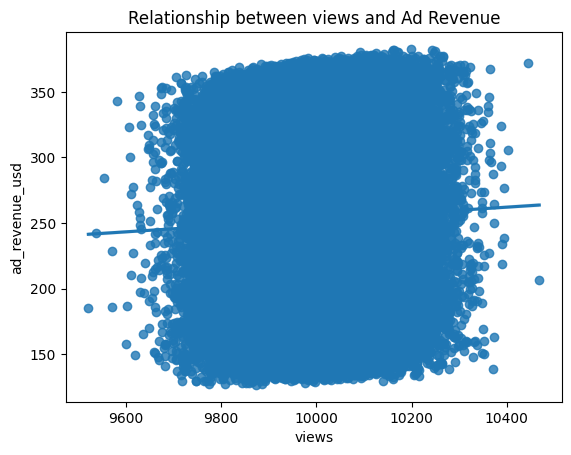

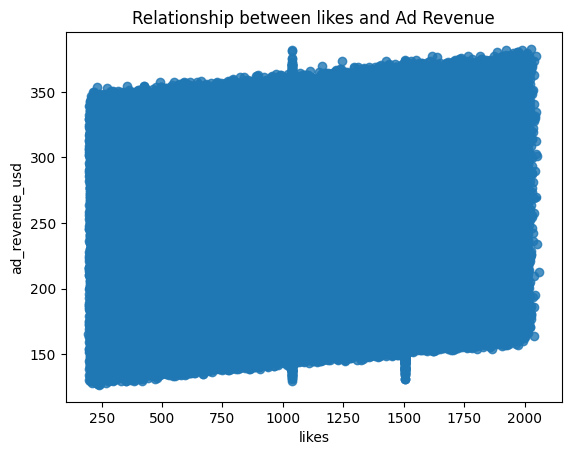

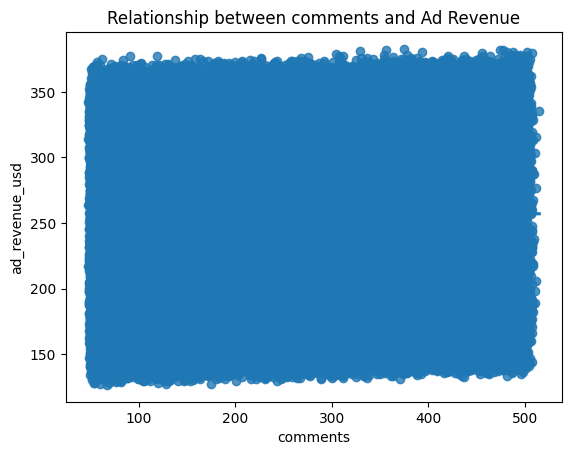

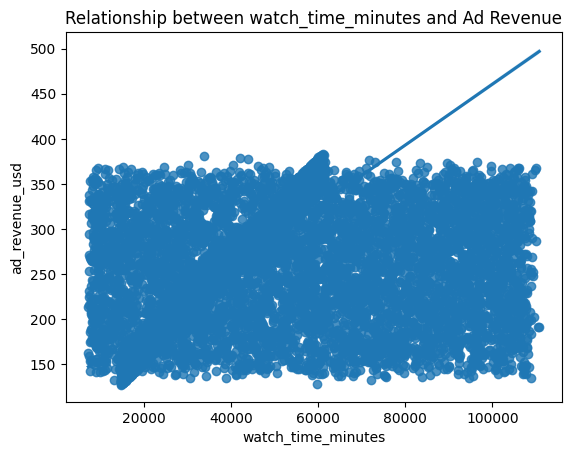

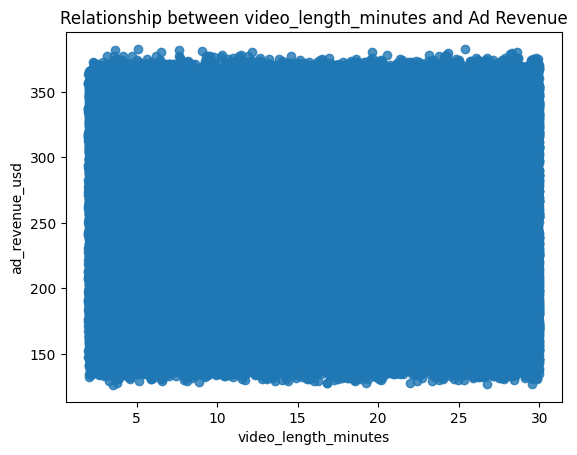

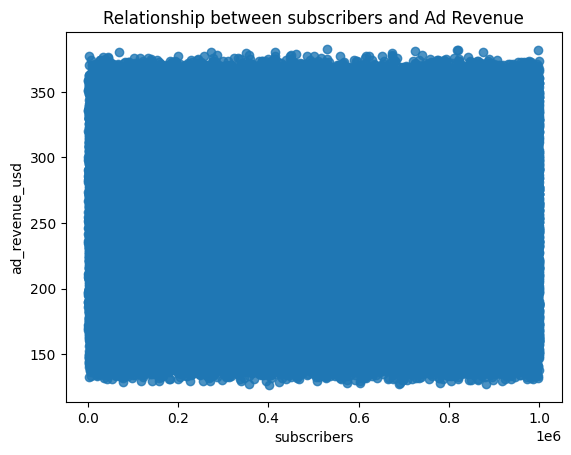

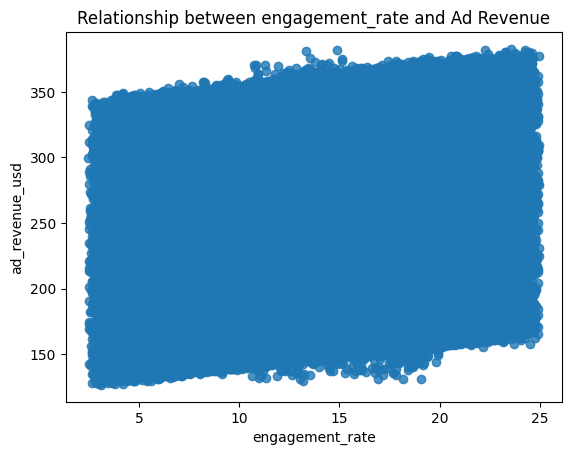

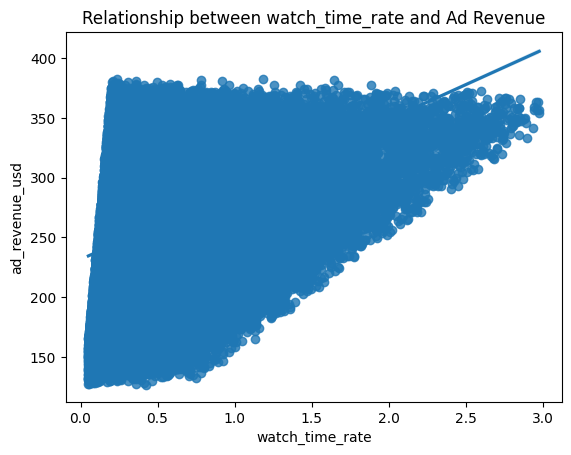

In [45]:
for col in num_cont:
    sns.regplot(df,x=df[col],y=df["ad_revenue_usd"])
    plt.title(f"Relationship between {col} and Ad Revenue")
    plt.xlabel(col)
    plt.ylabel("ad_revenue_usd")
    plt.show()

In [46]:
for col in num_cont:
    correlation = df[col].corr(df['ad_revenue_usd'])
    print(f'{col} , Correlation: {correlation} ')

views , Correlation: 0.03794165856253056 
likes , Correlation: 0.14172046171033745 
comments , Correlation: 0.038260371548830045 
watch_time_minutes , Correlation: 0.8169641765276554 
video_length_minutes , Correlation: 0.0003640697690700728 
subscribers , Correlation: 0.0050649520569861365 
engagement_rate , Correlation: 0.14421350210826156 
watch_time_rate , Correlation: 0.3345373687563728 


In [47]:
print(df[['watch_time_minutes', 'watch_time_rate']].corr())

                    watch_time_minutes  watch_time_rate
watch_time_minutes            1.000000         0.293808
watch_time_rate               0.293808         1.000000


In [48]:
print(df[['likes','engagement_rate','comments']].corr())

                    likes  engagement_rate  comments
likes            1.000000         0.969724  0.046028
engagement_rate  0.969724         1.000000  0.286988
comments         0.046028         0.286988  1.000000


In [49]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,watch_time_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,Tv,IN,203.178237,15.509259,0.931748
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,9.863233,0.063964
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,Tv,CA,360.134008,21.451916,0.216719
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,14.281443,0.265314
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,23.612094,0.238726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673,147,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,18.471532,0.167529
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709,63,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,17.496051,0.350211
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700,173,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,8.502971,0.112639
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616,106,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,16.816406,0.717548


In [50]:
num_feat=['watch_time_minutes','watch_time_rate','engagement_rate']

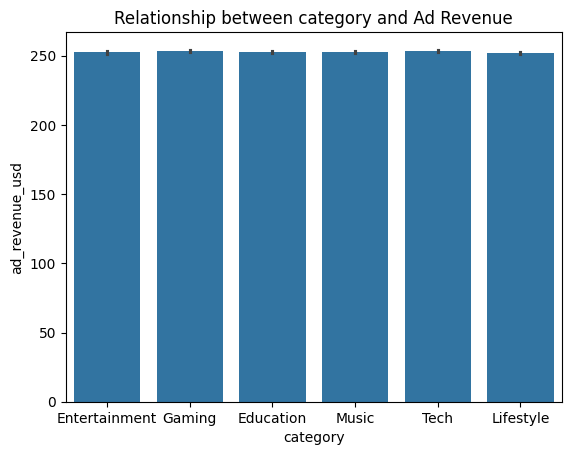

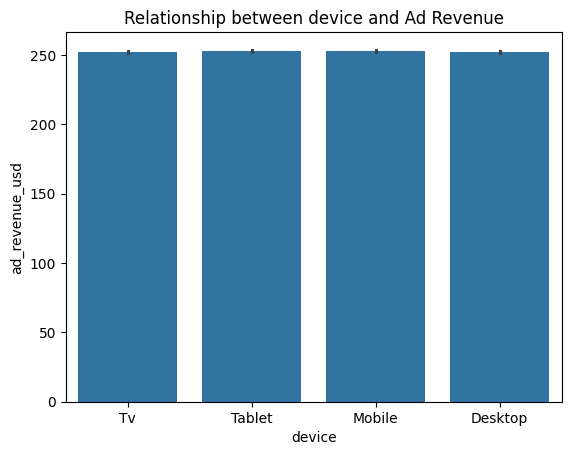

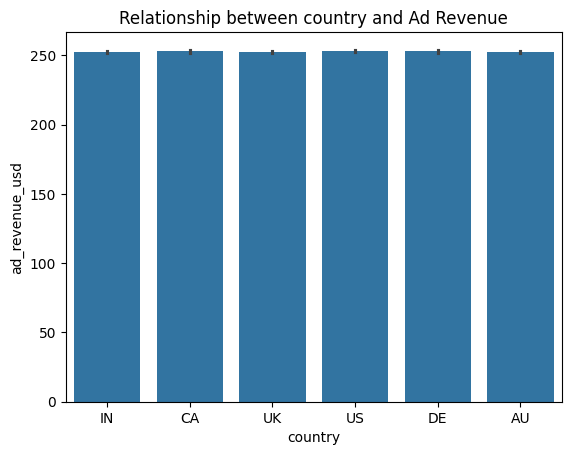

In [51]:
for col in cat:
    sns.barplot(df,x=df[col],y=df["ad_revenue_usd"])
    plt.title(f"Relationship between {col} and Ad Revenue")
    plt.xlabel(col)
    plt.ylabel("ad_revenue_usd")
    plt.show()

In [52]:
from scipy import stats

In [53]:
for col in cat:
    # 1. This splits the 'ad_revenue_usd' into separate lists for each group
    # (e.g., one list for 'Gaming', one for 'Finance', one for 'Tech')
    groups = [group_data["ad_revenue_usd"] for name, group_data in df.groupby(col)]

In [54]:
for col in cat:
    # 1. This creates the 'piles' of revenue for each group in the column
    groups = [data['ad_revenue_usd'] for name, data in df.groupby(col)]
    
    # 2. This runs the ANOVA test on those piles
    f_stat, p_value = stats.f_oneway(*groups)
    
    # 3. Show the result
    print(f"Checking {col}...")
    print(f"P-Value: {p_value}")
    
    if p_value < 0.05:
        print("Conclusion: This column MATTERS for revenue!")
    else:
        print("Conclusion: This column doesn't really affect revenue.")
    print("-" * 20)

Checking category...
P-Value: 0.08788330768624167
Conclusion: This column doesn't really affect revenue.
--------------------
Checking device...
P-Value: 0.14233571344953552
Conclusion: This column doesn't really affect revenue.
--------------------
Checking country...
P-Value: 0.8618687432412707
Conclusion: This column doesn't really affect revenue.
--------------------


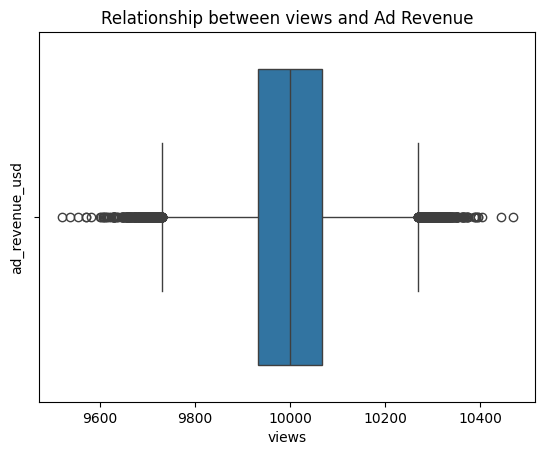

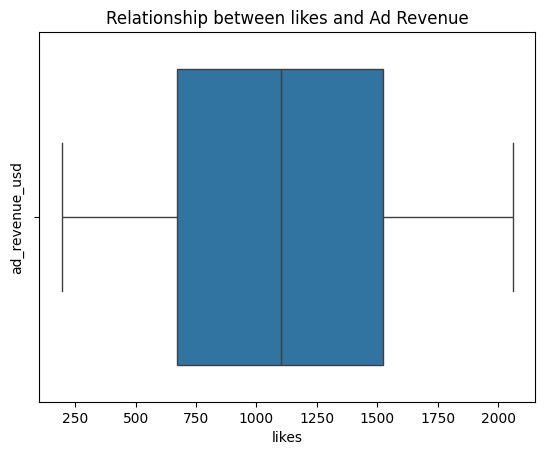

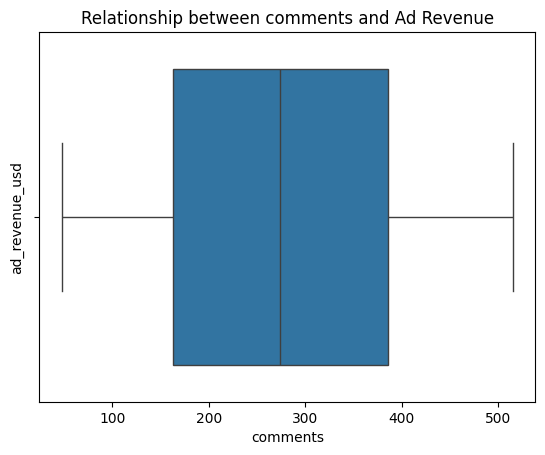

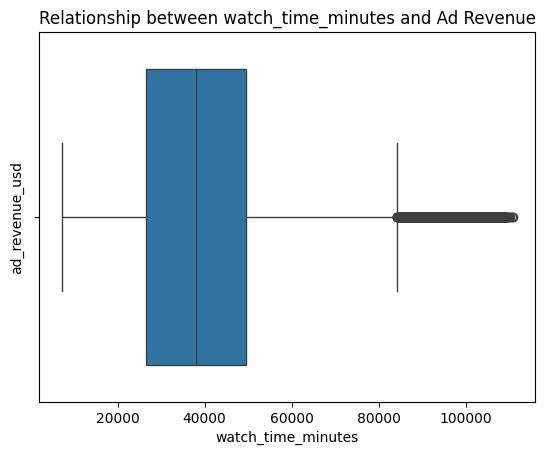

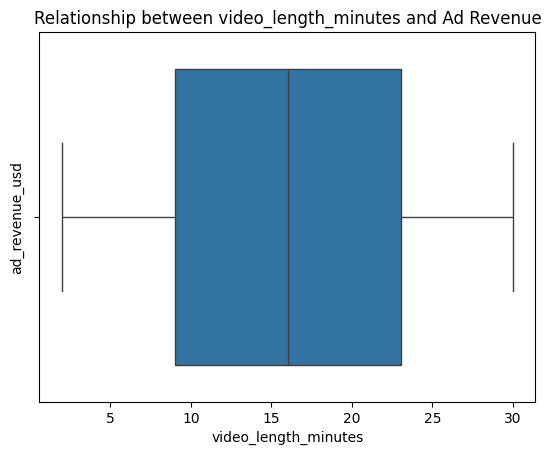

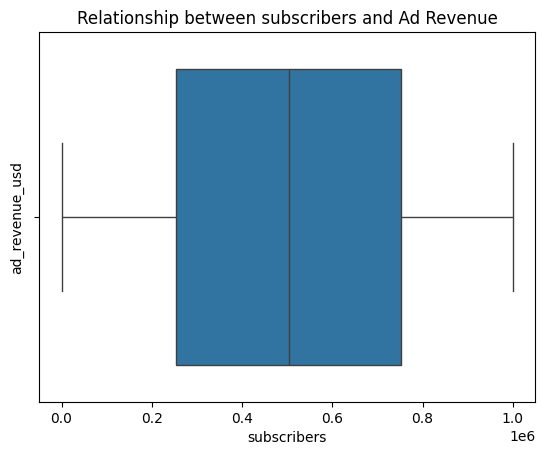

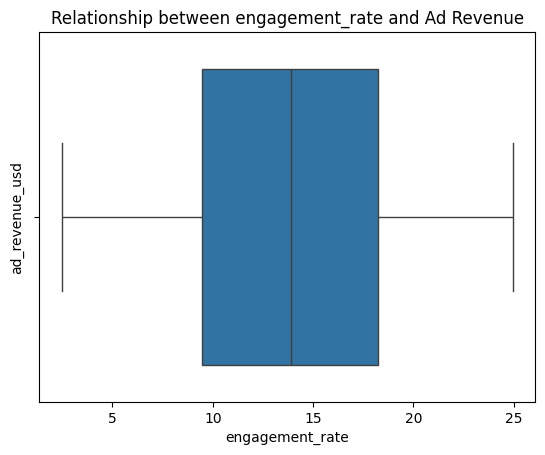

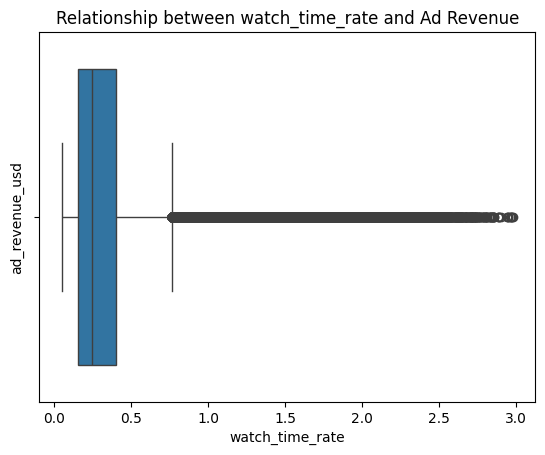

In [55]:
for col in num_cont:
    sns.boxplot(df,x=df[col])
    plt.title(f"Relationship between {col} and Ad Revenue")
    plt.xlabel(col)
    plt.ylabel("ad_revenue_usd")
    plt.show()

In [56]:
%pip install scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [57]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [58]:
cat_feat=['category']

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
import category_encoders as ce

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

In [60]:
preprocessor=ColumnTransformer(transformers=[('numeric',RobustScaler(),num_feat),('category',ce.BinaryEncoder(),cat_feat)])

model_pipeline=Pipeline(steps=[('preprocessor',preprocessor),('poly',PolynomialFeatures(degree=5, interaction_only=True, include_bias=False)),('LinearRegression',LinearRegression())])

In [61]:
preprocessor

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [62]:
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [63]:
a = df[num_feat + cat_feat]
b = df['ad_revenue_usd']

In [64]:
a

,watch_time_minutes,watch_time_rate,engagement_rate,category
0,26497.214184,0.931748,15.509259,Entertainment
1,15209.747445,0.063964,9.863233,Gaming
2,57332.658498,0.216719,21.451916,Education
3,31334.517771,0.265314,14.281443,Entertainment
4,15665.666434,0.238726,23.612094,Education
...,...,...,...,...
122395,42075.704885,0.167529,18.471532,Education
122396,57563.703040,0.350211,17.496051,Music
122397,27549.714659,0.112639,8.502971,Tech
122398,56967.384382,0.717548,16.816406,Music


In [65]:
b

0         203.178237
1         140.880508
2         360.134008
3         224.638261
4         165.514388
             ...    
122395    280.986396
122396    354.612981
122397    203.643106
122398    351.525811
122399    253.842824
Name: ad_revenue_usd, Length: 120000, dtype: float64

In [66]:
num_feat = ['watch_time_minutes', 'watch_time_rate', 'engagement_rate']
cat_feat = ['category']

X = df[num_feat + cat_feat]
y = df['ad_revenue_usd']

# 2. Split (ensure the order: X_train, X_test, y_train, y_test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use log1p to safely handle any potential 0 values

# 3. Fit the pipeline (Python is case-sensitive, use X_train not x_train)
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [67]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.71
RMSE: 33.3
MAE: 19.8


In [68]:
from sklearn.ensemble import RandomForestRegressor
model_pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300,max_depth=30,min_samples_split=10, random_state=42))
])

model_pipeline2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [69]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline2.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.94
RMSE: 15.2
MAE: 4.6


In [70]:
y_pred = model_pipeline2.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         353.164995        0.311474
1      341.983788         338.499371        3.484417
2      204.586883         209.007877        4.420994
3      176.835670         176.549122        0.286548
4      270.842839         269.728080        1.114759
5      287.477455         287.846315        0.368860
6      259.938374         255.892216        4.046158
7      261.089317         266.057684        4.968367
8      275.035544         275.208125        0.172581
9      307.006351         306.422918        0.583433

Overall Mean Absolute Error: $4.57


In [71]:
from sklearn.ensemble import GradientBoostingRegressor
model_pipeline3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100,max_depth=5,min_samples_split=10,learning_rate=0.1, random_state=42))
])

model_pipeline3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [72]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline3.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.95
RMSE: 13.9
MAE: 4.0


In [73]:
y_pred = model_pipeline3.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         353.536985        0.683465
1      341.983788         340.997250        0.986539
2      204.586883         206.815892        2.229009
3      176.835670         175.720440        1.115230
4      270.842839         270.762094        0.080745
5      287.477455         286.070360        1.407094
6      259.938374         258.351804        1.586570
7      261.089317         260.174648        0.914669
8      275.035544         273.595324        1.440220
9      307.006351         306.315040        0.691311

Overall Mean Absolute Error: $4.01


In [74]:
from sklearn.linear_model import Lasso
model_pipeline4=Pipeline(steps=[('preprocessor',preprocessor),('lasso',Lasso(alpha=0.1))])
model_pipeline4.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [75]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline4.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.71
RMSE: 33.4
MAE: 20.0


In [76]:
y_pred = model_pipeline4.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         315.224180       37.629340
1      341.983788         317.443997       24.539792
2      204.586883         214.510094        9.923211
3      176.835670         198.929239       22.093569
4      270.842839         256.514513       14.328326
5      287.477455         271.473770       16.003685
6      259.938374         250.637298        9.301076
7      261.089317         249.360883       11.728434
8      275.035544         258.474271       16.561273
9      307.006351         282.077894       24.928457

Overall Mean Absolute Error: $19.99


In [77]:
from sklearn.linear_model import Ridge
model_pipeline5=Pipeline(steps=[('preprocessor',preprocessor),('Ridge',Ridge(alpha=50))])
model_pipeline5.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [78]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline5.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.71
RMSE: 33.4
MAE: 19.9


In [79]:
y_pred = model_pipeline5.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         315.202868       37.650653
1      341.983788         317.928987       24.054802
2      204.586883         214.333711        9.746828
3      176.835670         199.141232       22.305562
4      270.842839         256.110998       14.731842
5      287.477455         271.532451       15.945003
6      259.938374         250.510088        9.428285
7      261.089317         249.289231       11.800086
8      275.035544         258.295031       16.740513
9      307.006351         281.989948       25.016403

Overall Mean Absolute Error: $19.94


In [80]:
import joblib
# Save your absolute best model for the Streamlit App
joblib.dump(model_pipeline3, 'final_revenue_model.pkl')

['final_revenue_model.pkl']

In [81]:
df.to_csv("youtube_ad_revenue_cleaned_dataset.csv")

In [82]:
%pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 7.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqla

In [83]:
import pandas as pd
from sqlalchemy import create_engine

# PostgreSQL connection details
username = "postgres"
password = "root"
host = "localhost"
port = "5432"
database = "content_monetization"

# File path
file_path = r"C:\Users\ASUS\Desktop\Projects\Content_monetization_modeler\youtube_ad_revenue_cleaned_dataset.csv"

# Read CSV
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\Content_monetization_modeler\data\cleaned data\youtube_ad_revenue_cleaned_dataset.csv")

# Drop unwanted index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convert date column
df["date"] = pd.to_datetime(df["date"]).dt.date

# Create engine
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Upload to PostgreSQL
df.to_sql(
    name="youtube_ad_revenue",
    con=engine,
    if_exists="append",   # use "replace" if you want to overwrite table
    index=False
)

print("Data uploaded successfully to PostgreSQL.")

Data uploaded successfully to PostgreSQL.
